# Inverse Modeling: Physics-based vs. Data-driven

Recover **Young's Modulus ($E$)** and **Poisson's ratio ($\nu$)** of a cantilever beam from 40 sensor measurements (20 displacements $y_q$ + 20 axial strains $\epsilon_{xx}$). True values: $E = 65{,}000$ Pa, $\nu = 0.29$.

| Method | Strategy | Key property |
|---|---|---|
| **JAX-FEM Gradient** | Physics-based | Exact gradients via adjoint AD; no training data needed |
| **CRPS** | Data-driven | Stochastic network, energy score objective; gives posterior ensemble |
| **MDN** | Data-driven | Gaussian mixture, maximum likelihood; gives full $p(q\mid y)$ |

In [9]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import pandas as pd
import uncertain_variables as uv
import matplotlib.pyplot as plt
import torch
import logging
import basix

from jax_fem.problem import Problem
from jax_fem.solver import ad_wrapper
from jax_fem.generate_mesh import box_mesh, Mesh, get_meshio_cell_type
from jax_fem.basis import get_elements

import sys, os
sys.path.append(os.path.abspath('..'))
from inverse_modeling import CRPSModel, MDNModel, JaxFemGradientModel
from inverse_modeling.calibration import gradient_based_model_calibration

logging.getLogger("jax_fem").setLevel(logging.WARNING)

## 1. Physics Setup

Isotropic linear elasticity on a $5 \times 1 \times 1$ m beam. Clamped at $x=0$, 100 N downward traction at $x=5$.

In [10]:
class CantileverElasticity(Problem):
    def get_tensor_map(self):
        def stress(u_grad, E, nu):
            mu  = E / (2.0 * (1.0 + nu))
            lam = (E * nu) / ((1.0 + nu) * (1.0 - 2.0 * nu))
            eps = 0.5 * (u_grad + u_grad.T)
            return lam * jnp.trace(eps) * jnp.eye(self.dim) + 2.0 * mu * eps
        return stress

    def get_surface_maps(self):
        return [lambda u, x: jnp.array([0.0, -100.0, 0.0])]

    def set_params(self, params):
        self.internal_vars = params

def left_boundary(x):  return jnp.isclose(x[0], 0.0)
def right_boundary(x): return jnp.isclose(x[0], 5.0)

def get_shape_grads_physical(problem):
    fe = problem.fes[0]
    element_family, basix_ele, _, _, degree, re_order = get_elements(fe.ele_type)
    element       = basix.create_element(element_family, basix_ele, degree)
    node_points   = element.points
    vals_and_grads = element.tabulate(1, node_points)[:, :, re_order, :]
    shape_grads_ref = jnp.transpose(vals_and_grads[1:, :, :, 0], axes=(1, 2, 0))
    physical_coos   = fe.points[fe.cells]
    jac = jnp.sum(physical_coos[:, None, :, :, None] * shape_grads_ref[None, :, :, None, :], axis=2, keepdims=True)
    return (shape_grads_ref[None, :, :, None, :] @ jnp.linalg.inv(jac))[:, :, :, 0, :]

## 2. Mesh, Sensors & Training Data

$10 \times 2 \times 2$ HEX8 mesh. 20 sensor nodes randomly selected from non-clamped interior nodes. Training set: 100 FEM simulations with $(E, \nu)$ drawn from a uniform prior.

In [11]:
Nx, Ny, Nz = 10, 2, 2
raw_mesh = box_mesh(Nx=Nx, Ny=Ny, Nz=Nz, domain_x=5.0, domain_y=1.0, domain_z=1.0)
mesh     = Mesh(raw_mesh.points, raw_mesh.cells_dict[get_meshio_cell_type('HEX8')])
problem  = CantileverElasticity(mesh, vec=3, dim=3, ele_type='HEX8',
    dirichlet_bc_info=[[left_boundary]*3, [0,1,2], [lambda x: 0.]*3],
    location_fns=[right_boundary])
fwd_pred         = ad_wrapper(problem)
shape_grads_phys = get_shape_grads_physical(problem)

def get_node_idx(i, j, k): return i * (Ny + 1) * (Nz + 1) + j * (Nz + 1) + k
np.random.seed(42)
sensor_node_indices = np.random.choice(
    [get_node_idx(i, j, k) for i in range(1, Nx) for j in range(Ny+1) for k in range(Nz+1)],
    20, replace=False)

node_to_cell_map = {}
for c, cell in enumerate(mesh.cells):
    for l, g in enumerate(cell):
        if int(g) in sensor_node_indices and int(g) not in node_to_cell_map:
            node_to_cell_map[int(g)] = (c, l)

def run_fem(E, nu):
    u    = fwd_pred([jnp.full((mesh.cells.shape[0], 8), E), jnp.full((mesh.cells.shape[0], 8), nu)])[0]
    y_q  = u[sensor_node_indices, 1]
    eps_xx = [
        jnp.sum(u[mesh.cells[node_to_cell_map[int(g)][0]], :, None] *
                shape_grads_phys[node_to_cell_map[int(g)][0], node_to_cell_map[int(g)][1], :, None, :],
                axis=0)[0, 0]
        for g in sensor_node_indices
    ]
    return jnp.concatenate([y_q, jnp.stack(eps_xx)])

Q = uv.VariableSet()
Q.add(uv.Variable('E',  uv.UniformDistribution(70000*0.85, 70000*1.15)))
Q.add(uv.Variable('nu', uv.UniformDistribution(0.28, 0.32)))

num_samples = 100
q_i = Q.sample(num_samples, method='QMC_Halton')
y_i = np.array([run_fem(q[0], q[1]) for q in q_i])
qoi_names = [f'y_q_{i}' for i in range(20)] + [f'eps_xx_{i}' for i in range(20)]
df_y = pd.DataFrame(y_i, columns=qoi_names)
df_q = pd.DataFrame(q_i, columns=['E', 'nu'])

In [12]:
import plotly.graph_objects as go

# Representative deformed config using mean training parameters
E_rep = float(q_i[:, 0].mean())
nu_rep = float(q_i[:, 1].mean())
u_rep = fwd_pred([jnp.full((mesh.cells.shape[0], 8), E_rep),
                  jnp.full((mesh.cells.shape[0], 8), nu_rep)])[0]
points_def = mesh.points + np.array(u_rep)
disp_mag = np.linalg.norm(np.array(u_rep), axis=1)
sensor_def = points_def[sensor_node_indices]

fig = go.Figure()

# Undeformed mesh (background reference)
fig.add_trace(go.Scatter3d(
    x=mesh.points[:, 0], y=mesh.points[:, 1], z=mesh.points[:, 2],
    mode='markers',
    marker=dict(size=2, color='lightgray', opacity=0.35),
    name='Undeformed'
))

# Deformed nodes coloured by displacement magnitude
fig.add_trace(go.Scatter3d(
    x=points_def[:, 0], y=points_def[:, 1], z=points_def[:, 2],
    mode='markers',
    marker=dict(
        size=4,
        color=disp_mag,
        colorscale='Jet',
        colorbar=dict(title='|u| [m]', x=0.85),
        opacity=0.85
    ),
    name='Deformed'
))

# Sensor nodes on deformed mesh
fig.add_trace(go.Scatter3d(
    x=sensor_def[:, 0], y=sensor_def[:, 1], z=sensor_def[:, 2],
    mode='markers',
    marker=dict(size=9, color='crimson', symbol='diamond', opacity=1.0),
    name='Sensors'
))

fig.update_layout(
    title=f'Deformed Cantilever — Sensor Placement (E={E_rep/1000:.0f} kPa, ν={nu_rep:.3f})',
    scene=dict(
        xaxis_title='X [m]', yaxis_title='Y [m]', zaxis_title='Z [m]',
        aspectmode='data'
    ),
    legend=dict(x=0.01, y=0.99),
    width=950, height=620
)
fig.show()


## 3. JAX-FEM Gradient Based Calibration

Minimises $\mathcal{L}(q) = \frac{1}{n}\|u(q)\big|_{\text{sensors}} - y_m\|^2$ via `jax.value_and_grad` through the full FEM solve.  
Parameters are normalised to $[0,1]$ before optimisation so a single learning rate is effective across $E \sim \mathcal{O}(10^4)$ and $\nu \sim \mathcal{O}(10^{-1})$.

In [13]:
E_true, nu_true = 65000.0, 0.29
y_m = run_fem(E_true, nu_true)

def params_fn(params):
    return [jnp.full((mesh.cells.shape[0], 8), params[0]),
            jnp.full((mesh.cells.shape[0], 8), params[1])]

def qoi_fn(u, mesh):
    y_q = u[sensor_node_indices, 1]
    eps_xx = [
        jnp.sum(u[mesh.cells[node_to_cell_map[int(g)][0]], :, None] *
                shape_grads_phys[node_to_cell_map[int(g)][0], node_to_cell_map[int(g)][1], :, None, :],
                axis=0)[0, 0]
        for g in sensor_node_indices
    ]
    return jnp.concatenate([y_q, jnp.stack(eps_xx)])

jax_fem_model = JaxFemGradientModel(
    Q, qoi_names, CantileverElasticity, mesh,
    params_fn=params_fn, qoi_fn=qoi_fn,
    problem_args={'vec': 3, 'dim': 3, 'ele_type': 'HEX8',
                  'dirichlet_bc_info': [[left_boundary]*3, [0,1,2], [lambda x: 0.]*3],
                  'location_fns': [right_boundary]}
)

q_id_grad, grad_history = gradient_based_model_calibration(
    jax_fem_model, y_m, steps=100, learning_rate=150.0, verbose=False, return_history=True
)
print(f"Gradient result:  E = {q_id_grad[0]:.1f} Pa,  nu = {q_id_grad[1]:.4f}")
print(f"True values:      E = {E_true:.1f} Pa,  nu = {nu_true:.4f}")

Gradient result:  E = 64734.7 Pa,  nu = 0.2993
True values:      E = 65000.0 Pa,  nu = 0.2900


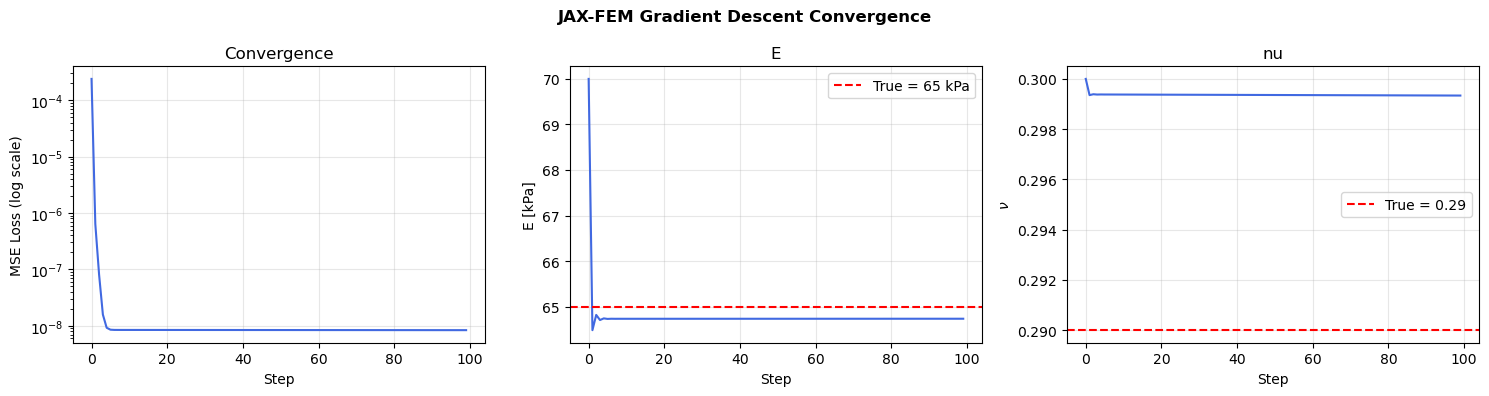

In [14]:
steps_h = [h['step']      for h in grad_history]
losses_h = [h['loss']      for h in grad_history]
E_hist   = [h['params'][0] for h in grad_history]
nu_hist  = [h['params'][1] for h in grad_history]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(steps_h, losses_h, 'royalblue')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('MSE Loss (log scale)')
axes[0].set_title('Convergence'); axes[0].grid(True, alpha=0.3)

axes[1].plot(steps_h, [e/1000 for e in E_hist], 'royalblue')
axes[1].axhline(E_true/1000, color='red', linestyle='--', label=f'True = {E_true/1000:.0f} kPa')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('E [kPa]')
axes[1].set_title("E"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(steps_h, nu_hist, 'royalblue')
axes[2].axhline(nu_true, color='red', linestyle='--', label=f'True = {nu_true}')
axes[2].set_xlabel('Step'); axes[2].set_ylabel(r'$\nu$')
axes[2].set_title("nu"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('JAX-FEM Gradient Descent Convergence', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Probabilistic Inverse Modeling

Both networks are trained as direct inverse models ($y \to q$) on the 100 FEM simulations. Inference is a single forward pass — orders of magnitude faster than gradient calibration at the cost of upfront data generation.

- **CRPS:** injects $\varepsilon \sim \mathcal{N}(0,I)$ each forward pass; trained with multivariate energy score → calibrated ensemble.
- **MDN:** outputs $(K=3)$ Gaussian mixture parameters; trained by maximum log-likelihood → explicit $p(q\mid y)$.

In [15]:
crps_model = CRPSModel(Q, qoi_names)
crps_model.train(df_y, df_q, epochs=150, batch_size=8)

mdn_model = MDNModel(Q, qoi_names, num_components=3)
mdn_model.train(df_y, df_q, epochs=200, batch_size=8, lr=3e-4)

q_pred_crps = crps_model.predict(y_m.reshape(1, -1))
q_pred_mdn  = mdn_model.predict(y_m.reshape(1, -1))

print(f"CRPS: E = {q_pred_crps['E'].values[0]:.1f} Pa,  nu = {q_pred_crps['nu'].values[0]:.4f}")
print(f"MDN:  E = {q_pred_mdn['E'].values[0]:.1f} Pa,   nu = {q_pred_mdn['nu'].values[0]:.4f}")

----- Training started for 'CRPS' inverse model -----
Epoch 0: Train Loss = 0.628911, Val Loss = 0.651192
Epoch 10: Train Loss = 0.169084, Val Loss = 0.163373
Epoch 20: Train Loss = 0.163852, Val Loss = 0.131088
Epoch 30: Train Loss = 0.161156, Val Loss = 0.176402
Epoch 40: Train Loss = 0.133377, Val Loss = 0.155078
Early stopping at epoch 44
----- Training ended for 'CRPS' inverse model -----
----- Training started for 'MDN' inverse model -----
Epoch 0: Train Loss = 1.679495, Val Loss = 1.743120
Epoch 10: Train Loss = -0.589976, Val Loss = -0.993825
Epoch 20: Train Loss = -1.631655, Val Loss = -1.688267
Epoch 30: Train Loss = -2.410191, Val Loss = -1.583742
Epoch 40: Train Loss = -2.316204, Val Loss = -2.440634
Epoch 50: Train Loss = -2.665585, Val Loss = -2.761202
Epoch 60: Train Loss = -2.208789, Val Loss = -2.778909
Epoch 70: Train Loss = -3.133661, Val Loss = -2.603593
Epoch 80: Train Loss = -3.057202, Val Loss = -1.883653
Epoch 90: Train Loss = -2.779934, Val Loss = -2.705249
Epo

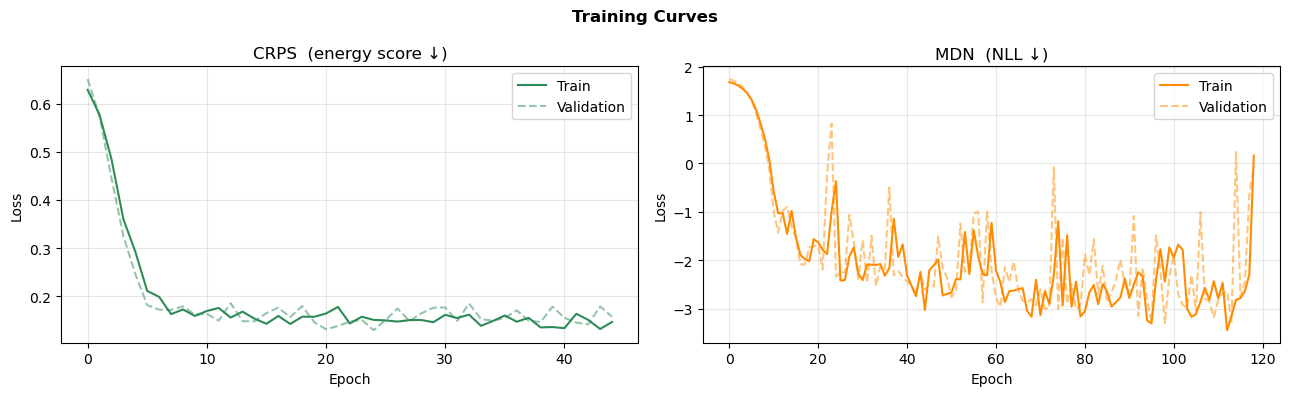

In [16]:
crps_hist = pd.DataFrame(crps_model.history)
mdn_hist  = pd.DataFrame(mdn_model.history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, hist, title, color in [
    (axes[0], crps_hist, 'CRPS  (energy score ↓)', 'seagreen'),
    (axes[1], mdn_hist,  'MDN  (NLL ↓)',           'darkorange'),
]:
    ax.plot(hist['epoch'], hist['train_loss'], color=color,         label='Train', linewidth=1.5)
    ax.plot(hist['epoch'], hist['val_loss'],   color=color, alpha=0.5,
            linestyle='--', label='Validation', linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Results (Clean Measurements)

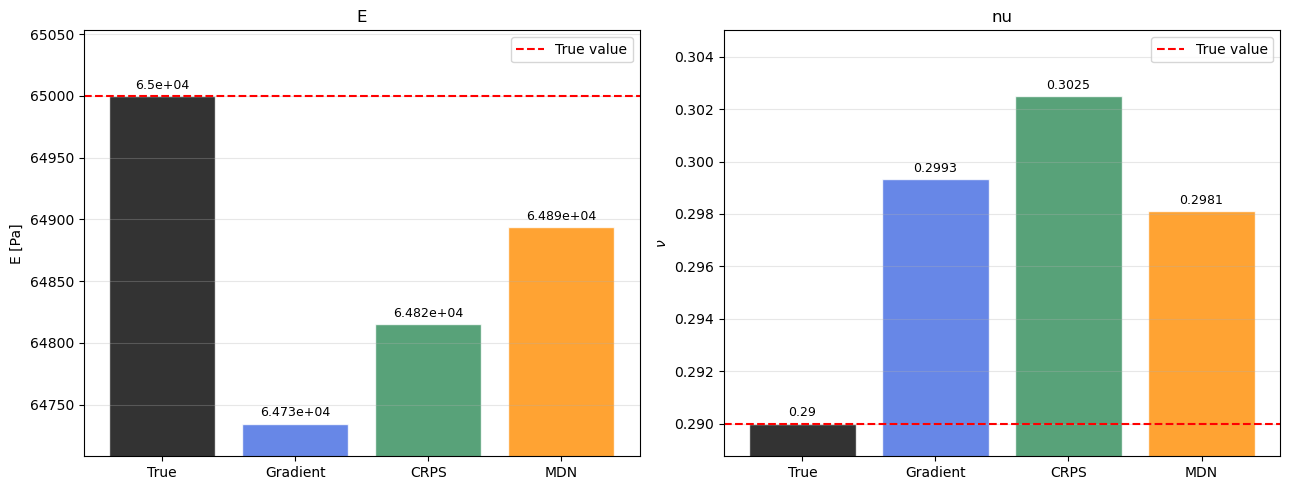

Method           E_pred   E_err%    nu_pred  nu_err%
------------------------------------------------------
Gradient        64734.7    0.41%     0.2993    3.22%
CRPS            64815.1    0.28%     0.3025    4.31%
MDN             64893.9    0.16%     0.2981    2.79%


In [17]:
methods = ['True', 'Gradient', 'CRPS', 'MDN']
colors  = ['black', 'royalblue', 'seagreen', 'darkorange']
E_vals  = [E_true, q_id_grad[0], q_pred_crps['E'].values[0],  q_pred_mdn['E'].values[0]]
nu_vals = [nu_true, q_id_grad[1], q_pred_crps['nu'].values[0], q_pred_mdn['nu'].values[0]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, vals, true_val, ylabel, title in [
    (axes[0], E_vals,  E_true,  'E [Pa]', "E"),
    (axes[1], nu_vals, nu_true, r'$\nu$', "nu"),
]:
    bars = ax.bar(methods, vals, color=colors, alpha=0.8, edgecolor='white')
    ax.axhline(true_val, color='red', linestyle='--', linewidth=1.5, label='True value')
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:.4g}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')
    _range = max(vals) - min(vals)
    ax.set_ylim(min(vals) - 0.1 * _range, max(vals) + 0.2 * _range)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Error table
print(f"{'Method':<12} {'E_pred':>10} {'E_err%':>8} {'nu_pred':>10} {'nu_err%':>8}")
print("-" * 54)
for name, E_p, nu_p in zip(methods[1:], E_vals[1:], nu_vals[1:]):
    print(f"{name:<12} {E_p:>10.1f} {abs(E_p-E_true)/E_true*100:>7.2f}%"
          f" {nu_p:>10.4f} {abs(nu_p-nu_true)/nu_true*100:>7.2f}%")

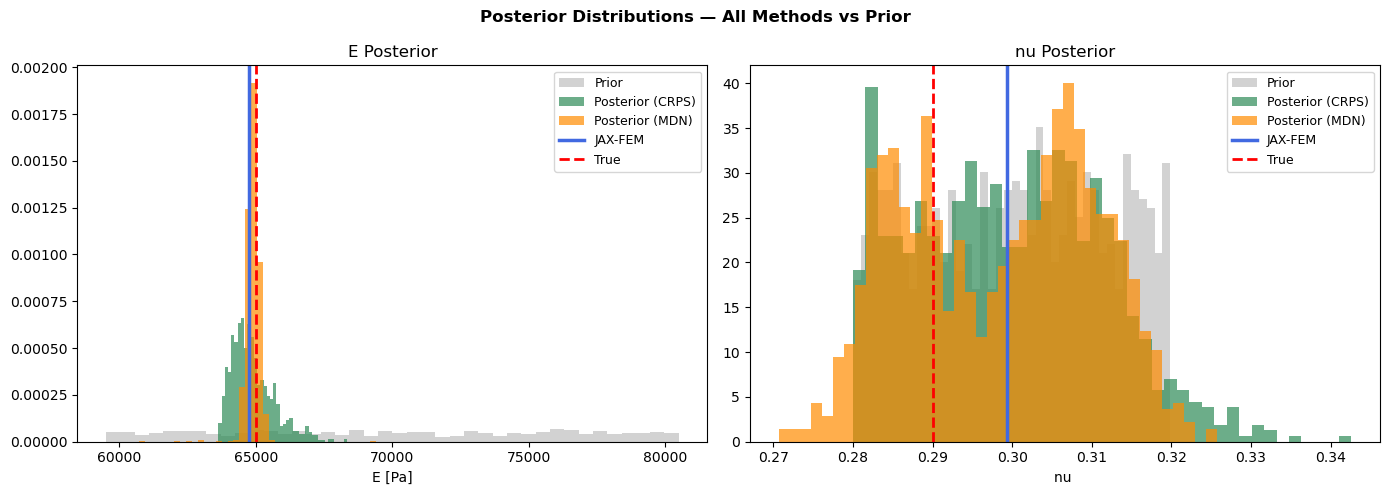

In [18]:
posterior_crps = crps_model.sample(y_m.reshape(1, -1), n_samples=1000)
posterior_mdn  = mdn_model.sample(y_m.reshape(1, -1),  n_samples=1000)
prior_q        = pd.DataFrame(Q.sample(1000), columns=['E', 'nu'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, param, grad_val, true_val, unit in [
    (axes[0], 'E',  q_id_grad[0], E_true,  '[Pa]'),
    (axes[1], 'nu', q_id_grad[1], nu_true, ''),
]:
    ax.hist(prior_q[param],        bins=40, density=True, alpha=0.35, color='gray',      label='Prior')
    ax.hist(posterior_crps[param], bins=40, density=True, alpha=0.7,  color='seagreen',  label='Posterior (CRPS)')
    ax.hist(posterior_mdn[param],  bins=40, density=True, alpha=0.7,  color='darkorange', label='Posterior (MDN)')
    ax.axvline(grad_val, color='royalblue', linewidth=2.5, label='JAX-FEM')
    ax.axvline(true_val, color='red', linestyle='--', linewidth=2, label='True')
    ax.set_title(f'{param} Posterior')
    ax.set_xlabel(f'{param} {unit}')
    ax.legend(fontsize=9)

plt.suptitle('Posterior Distributions — All Methods vs Prior', fontweight='bold')
plt.tight_layout()
plt.show()

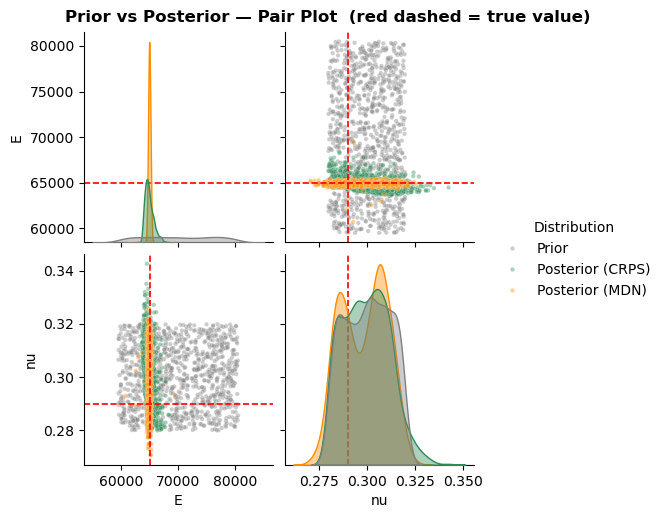

In [20]:
import seaborn as sns

# Combine prior and posterior samples into one DataFrame for pairplot
df_prior = prior_q.copy();            df_prior['Distribution'] = 'Prior'
df_post_crps = posterior_crps.copy(); df_post_crps['Distribution'] = 'Posterior (CRPS)'
df_post_mdn  = posterior_mdn.copy();  df_post_mdn['Distribution']  = 'Posterior (MDN)'

df_all = pd.concat([df_prior, df_post_crps, df_post_mdn], ignore_index=True)

palette = {'Prior': 'gray', 'Posterior (CRPS)': 'seagreen', 'Posterior (MDN)': 'darkorange'}

g = sns.pairplot(
    df_all, hue='Distribution', vars=['E', 'nu'],
    plot_kws=dict(alpha=0.4, s=10),
    diag_kws=dict(fill=True, alpha=0.4),
    palette=palette,
    diag_kind='kde', kind='scatter',
    corner=False
)

# Mark true values
for ax in g.axes.flat:
    if ax is None:
        continue
    xlabel, ylabel = ax.get_xlabel(), ax.get_ylabel()
    true_vals = {'E': E_true, 'nu': nu_true}
    if xlabel in true_vals:
        ax.axvline(true_vals[xlabel], color='red', linestyle='--', linewidth=1.2)
    if ylabel in true_vals:
        ax.axhline(true_vals[ylabel], color='red', linestyle='--', linewidth=1.2)

g.figure.suptitle('Prior vs Posterior — Pair Plot  (red dashed = true value)', y=1.02, fontweight='bold')
plt.show()

## 6. Robustness to Measurement Noise

Simulated sensor noise: 1% on $y_q$, 5% on $\epsilon_{xx}$ (strain gauges are noisier in practice).

The gradient method fits the noisy measurements exactly — it has no regularisation, so noise propagates directly into the estimated parameters. Data-driven models are implicitly regularised by the training distribution and tend to be more robust.

In [ ]:
np.random.seed(0)
y_m_noisy = np.array(y_m).copy()
y_m_noisy[:20] += np.random.normal(0, np.abs(y_m_noisy[:20]) * 0.01)
y_m_noisy[20:] += np.random.normal(0, np.abs(y_m_noisy[20:]) * 0.05)

q_noisy_grad = gradient_based_model_calibration(
    jax_fem_model, y_m_noisy, steps=50, learning_rate=100.0, verbose=False
)
q_noisy_crps = crps_model.predict(y_m_noisy.reshape(1, -1))
q_noisy_mdn  = mdn_model.predict(y_m_noisy.reshape(1, -1))

print(f"True:                E = {E_true:.1f},  nu = {nu_true:.4f}")
print(f"Gradient (noisy):    E = {q_noisy_grad[0]:.1f},  nu = {q_noisy_grad[1]:.4f}")
print(f"CRPS (noisy):        E = {q_noisy_crps['E'].values[0]:.1f},  nu = {q_noisy_crps['nu'].values[0]:.4f}")
print(f"MDN  (noisy):        E = {q_noisy_mdn['E'].values[0]:.1f},   nu = {q_noisy_mdn['nu'].values[0]:.4f}")

True:                E = 65000.0,  nu = 0.2900
Gradient (noisy):    E = 64390.3,  nu = 0.2993
CRPS (noisy):        E = 63425.9,  nu = 0.2994
MDN  (noisy):        E = 63967.7,   nu = 0.3035


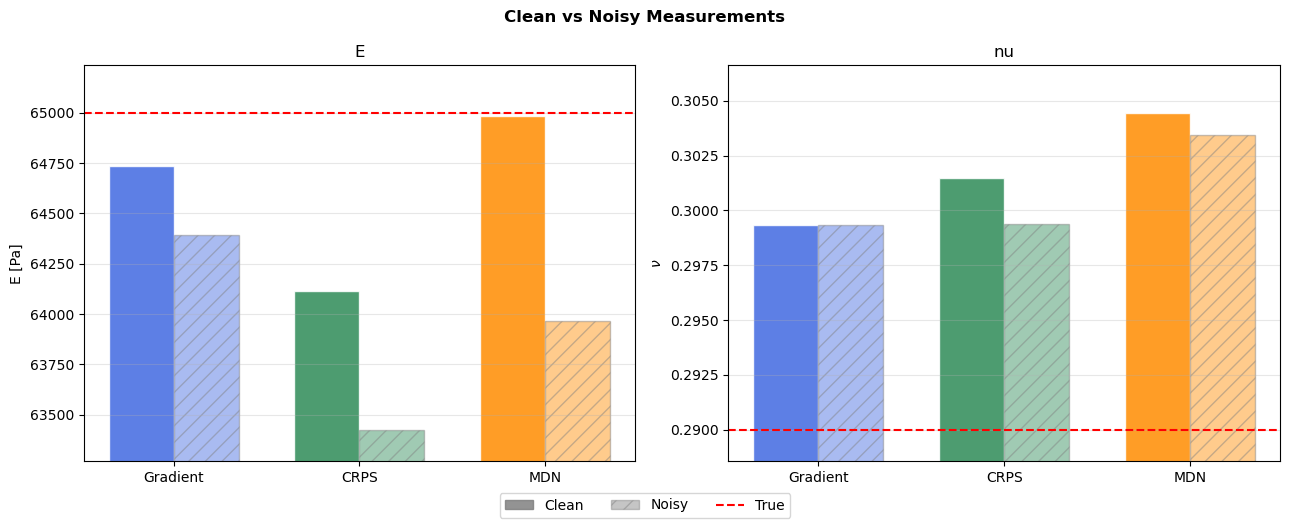

In [ ]:
method_labels = ['Gradient', 'CRPS', 'MDN']
bar_colors    = ['royalblue', 'seagreen', 'darkorange']

E_clean  = [q_id_grad[0],    q_pred_crps['E'].values[0],   q_pred_mdn['E'].values[0]]
E_noisy  = [q_noisy_grad[0], q_noisy_crps['E'].values[0],  q_noisy_mdn['E'].values[0]]
nu_clean = [q_id_grad[1],    q_pred_crps['nu'].values[0],  q_pred_mdn['nu'].values[0]]
nu_noisy = [q_noisy_grad[1], q_noisy_crps['nu'].values[0], q_noisy_mdn['nu'].values[0]]

x = np.arange(len(method_labels))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, clean_v, noisy_v, true_v, ylabel, title in [
    (axes[0], E_clean,  E_noisy,  E_true,  'E [Pa]',  "E"),
    (axes[1], nu_clean, nu_noisy, nu_true, r'$\nu$', "nu"),
]:
    b1 = ax.bar(x - w/2, clean_v, w, color=bar_colors, alpha=0.85, label='Clean', edgecolor='white')
    b2 = ax.bar(x + w/2, noisy_v, w, color=bar_colors, alpha=0.45, hatch='//', label='Noisy', edgecolor='gray')
    ax.axhline(true_v, color='red', linestyle='--', linewidth=1.5, label='True')
    ax.set_xticks(x); ax.set_xticklabels(method_labels)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.ticklabel_format(useOffset=False, style='plain', axis='y')
    _all = clean_v + noisy_v + [true_v]
    _range = max(_all) - min(_all)
    ax.set_ylim(min(_all) - 0.1 * _range, max(_all) + 0.15 * _range)
    ax.grid(True, alpha=0.3, axis='y')

# shared legend outside
handles = [
    plt.Rectangle((0,0),1,1, color='gray', alpha=0.85, label='Clean'),
    plt.Rectangle((0,0),1,1, color='gray', alpha=0.45, hatch='//', label='Noisy'),
    plt.Line2D([0],[0], color='red', linestyle='--', label='True'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Clean vs Noisy Measurements', fontweight='bold')
plt.tight_layout()
plt.show()